# **Travelling Salesman Problem (TSP): Hill Climbing and Tabu Search**

## MSc Artificial Intelligence — AI for Search & Optimisation

This notebook implements and compares two local search algorithms for the Travelling Salesman Problem (TSP):

- **Simple Hill Climbing**
- **Tabu Search with short-term memory**

The workflow reflects good practice for search and optimisation experiments:

1. Data loading and distance matrix construction  
2. Tour representation and objective function  
3. Neighbourhood definition (swap-based moves)  
4. Implementation of Simple Hill Climbing  
5. Implementation of Tabu Search (with tabu tenure and aspiration)  
6. Experimental setup and execution  
7. Visualisation of convergence behaviour  
8. Evaluation and discussion in the context of local search and metaheuristics  

The aim is to demonstrate understanding of both algorithms and to present results in a clear, reproducible format suitable for assessment.


## 1. Imports

We begin by loading all libraries required for optimisation, plotting and numerical computation. Imports are kept in one cell to avoid redundancy across the notebook.


In [33]:
import time
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Global random seed for reproducible experiments
np.random.seed(42)


## 2. Data Loading and Distance Matrix

We use the provided `cities.csv` file containing 2D coordinates (`X`, `Y`) for 50 cities.
These are treated as points in the Euclidean plane, and all algorithms operate on the **same** precomputed distance matrix so that differences in performance arise from the search strategy rather than inconsistent distance calculations.

The helper functions below:

- load the CSV into a Pandas DataFrame,
- compute pairwise Euclidean distances between all city pairs, and
- store the result in a dense NumPy matrix `dist_matrix` that is reused by Hill Climbing, Tabu Search, and the Genetic Algorithm.


In [34]:
def load_cities(path: str) -> pd.DataFrame:
    """Load city coordinates from CSV."""
    df = pd.read_csv(path)
    return df

def compute_distance(x1: float, y1: float, x2: float, y2: float) -> float:
    """Compute Euclidean distance between 2D points."""
    return float(np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2))

def create_distance_matrix(cities_df: pd.DataFrame) -> np.ndarray:
    """Build the full Euclidean distance matrix."""
    n_cities = len(cities_df)
    dist_mat = np.zeros((n_cities, n_cities), dtype=float)
    cords = cities_df[["X", "Y"]].to_numpy()
    for i in range(n_cities):
        for j in range(n_cities):
            xi, yi = cords[i]
            xj, yj = cords[j]
            dist_mat[i, j] = compute_distance(xi, yi, xj, yj)
    return dist_mat

# Load dataset
cities_path = "data/cities.csv"
cities_df = load_cities(cities_path)
dist_matrix = create_distance_matrix(cities_df)
n_cities = len(cities_df)

print("Loaded:", cities_df.shape)
print("Distance matrix:", dist_matrix.shape)


Loaded: (50, 3)
Distance matrix: (50, 50)


## 3. Tour Representation and Objective Function

A TSP tour is represented as a **permutation of city indices**, e.g.:

`[0, 5, 2, 1, 4, 3]`

This encoding is standard for TSP optimisation because:

- it ensures each city appears exactly once,
- it supports permutation-based operators such as **swap** and **2-opt**, and
- it is compatible with the crossover and mutation operators in the Genetic Algorithm.

### Initial Tour
The function `create_initial_tour` generates a valid random permutation.
This provides a neutral starting point for Hill Climbing, Tabu Search, and the Genetic Algorithm.

### Tour Validity
The helper `is_valid_tour` checks whether a tour contains all cities exactly once.
This is important for debugging neighbourhood operators and ensuring correctness.

### Objective Function
The objective is to **minimise total tour length**, computed by summing distances between consecutive cities, including returning to the starting city (closing the loop).
The function `tour_length` uses the precomputed distance matrix and is shared by all algorithms.

This section establishes the basic problem structure that all optimisation methods operate on.


In [35]:
def create_initial_tour(n_cities: int) -> np.ndarray:
    """Generate a random permutation of city indices."""
    tour = np.arange(n_cities)
    np.random.shuffle(tour)
    return tour


def is_valid_tour(tour: np.ndarray, n_cities: int) -> bool:
    """Check that the tour is a valid permutation of all cities."""
    return (len(tour) == n_cities) and (len(np.unique(tour)) == n_cities)


def tour_length(tour: np.ndarray, dist_matrix: np.ndarray) -> float:
    """Compute total distance of a tour (closed loop)."""
    length = 0.0
    for i in range(len(tour)):
        # (i + 1) % len(tour) wraps around to the first city at the end
        length += dist_matrix[tour[i], tour[(i + 1) % len(tour)]]
    return float(length)


**Tour as a cycle**

For a tour `[A, B, C, D]`, the evaluated edges are:

A → B → C → D → **A**


## 4. Neighbourhood Operators (Swap and 2-Opt)

Local search methods for the TSP require a **neighbourhood structure**:
a set of “nearby” solutions produced by modifying the current tour.
The neighbourhood determines:

- how the search space is explored,
- how easy it is to escape poor-quality regions,
- and how quickly algorithms converge.

This project uses two standard TSP neighbourhoods:

### **(1) Swap Neighbourhood (2-exchange)**
This operation selects two positions `i` and `j` in the tour and swaps the cities:
`[..., A, ..., B, ...] → [..., B, ..., A, ...]`.

Characteristics:
- Very small, conservative move
- Fast to evaluate
- Often leads to **local minima** that are hard to escape
- Useful as a baseline for understanding algorithm behaviour

I am using it to show the limitations of simple hill climbing and the benefit of Tabu Search or GA.

### **(2) 2-Opt Neighbourhood**
2-Opt removes two edges and reconnects the tour in the opposite direction.
For a segment `(i … j)` it reverses that section of the tour.

This is equivalent to:
`... A → B … C → D ...`
becoming
`... A → C … B → D ...`.

Properties:
- Removes crossing edges (a classical source of inefficiency)
- Produces large, meaningful structural improvements
- Much more powerful than simple swap
- Standard in many TSP heuristics (Croes, 1958)

**Why 2-Opt matters:**
Almost all performance differences you later observe between HC, TS, and GA are heavily influenced by whether the neighbourhood is *shallow* (swap) or *deep* (2-opt).

In [36]:
def swap_cities(tour: np.ndarray, i: int, j: int) -> np.ndarray:
    """Swap positions i and j in a tour."""
    new_tour = tour.copy()
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour


def generate_all_swap_neighbours(tour: np.ndarray):
    """Generate all swap neighbours by exchanging any two positions i < j."""
    neighbours = []
    n = len(tour)
    for i in range(n - 1):
        for j in range(i + 1, n):
            neighbours.append(swap_cities(tour, i, j))
    return neighbours


def generate_all_two_opt_neighbours(tour: np.ndarray):
    """Generate all 2-opt neighbours by reversing tour segments between i and j."""
    neighbours = []
    n = len(tour)
    for i in range(n - 1):
        for j in range(i + 2, n):
            new_tour = tour.copy()
            new_tour[i:j] = new_tour[i:j][::-1]
            neighbours.append(new_tour)
    return neighbours


## 5. Visualisation Utilities

These helper functions are used throughout the notebook to visualise algorithm performance:

- `plot_history` shows how the best solution improves over time.
- `plot_comparison` displays multiple convergence curves on the same graph.

They help interpret convergence speed, stability, and differences between search strategies.


In [45]:
def plot_history(history: List[float], title: str) -> None:
    plt.figure(figsize=(8, 4))
    plt.plot(history)
    plt.xlabel("Iteration / Generation")
    plt.ylabel("Best tour cost")
    plt.title(title)
    plt.grid(True)
    plt.show()


def plot_comparison(histories: List[List[float]], labels: List[str], title: str) -> None:
    plt.figure(figsize=(10, 5))
    for h, lbl in zip(histories, labels):
        plt.plot(h, label=lbl)
    plt.xlabel("Iteration / Generation")
    plt.ylabel("Best tour cost")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


## 6. Simple Hill Climbing

Hill Climbing evaluates a neighbourhood of candidate moves and greedily selects the best-improving tour. The search terminates when no improving neighbour exists.


In [38]:
def simple_hill_climbing(
    initial_tour: np.ndarray,
    dist_matrix: np.ndarray,
    max_iterations: int = 200,
    neighbourhood: str = "swap",
    sample_size: int | None = None,
):
    """Hill Climbing with swap or 2-opt neighbourhood."""
    current_tour = initial_tour.copy()
    current_cost = tour_length(current_tour, dist_matrix)
    best_tour = current_tour.copy()
    best_cost = current_cost
    history = [best_cost]

    for _ in range(max_iterations):

        # Select neighbourhood
        if neighbourhood == "swap":
            neighbours = generate_all_swap_neighbours(current_tour)
        elif neighbourhood == "2opt":
            neighbours = generate_all_two_opt_neighbours(current_tour)
        else:
            raise ValueError("Unknown neighbourhood.")

        # Optional subsampling for speed
        if sample_size and len(neighbours) > sample_size:
            idx = np.random.choice(len(neighbours), sample_size, replace=False)
            neighbours = [neighbours[i] for i in idx]

        # Find best neighbour
        candidate_tour = None
        candidate_cost = float("inf")
        for nb in neighbours:
            c = tour_length(nb, dist_matrix)
            if c < candidate_cost:
                candidate_tour, candidate_cost = nb, c

        # Accept or stop
        if candidate_cost < current_cost:
            current_tour = candidate_tour
            current_cost = candidate_cost
            best_tour = current_tour.copy()
            best_cost = current_cost
            history.append(best_cost)
        else:
            break

    return best_tour, best_cost, history


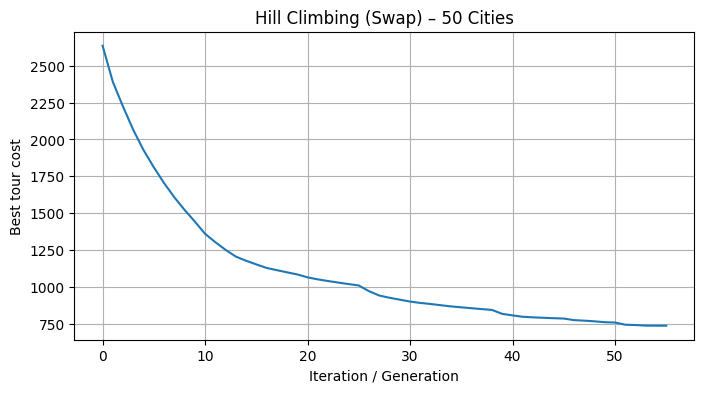

In [46]:
plot_history(single_results["HC_swap"]["history"], "Hill Climbing (Swap) – 50 Cities")


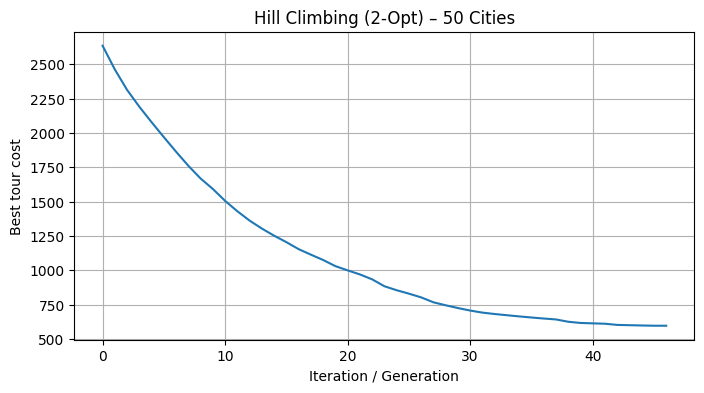

In [49]:
plot_history(single_results["HC_2opt"]["history"], "Hill Climbing (2-Opt) – 50 Cities")


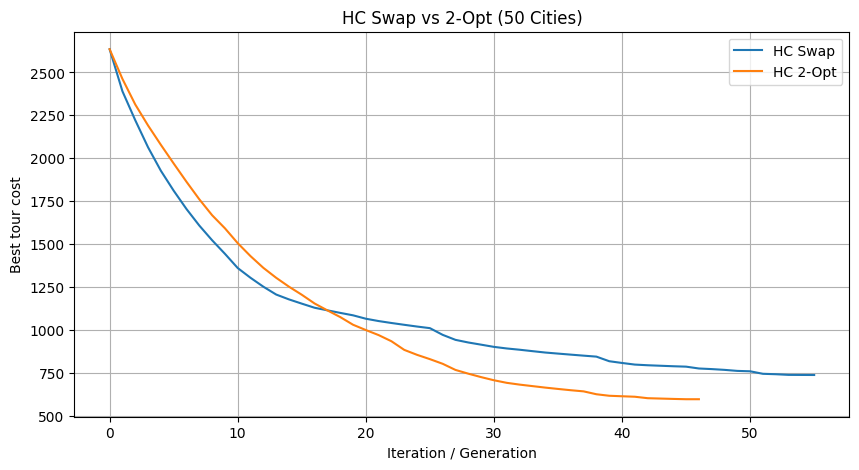

In [51]:
plot_comparison(
    [single_results["HC_swap"]["history"], single_results["HC_2opt"]["history"]],
    ["HC Swap", "HC 2-Opt"],
    "HC Swap vs 2-Opt (50 Cities)"
)


## 6. Tabu Search

Tabu Search (Glover, 1986; Glover & Laguna, 1997) is a memory-based metaheuristic designed to escape the local minima where hill climbing gets stuck.

### Core Ideas

Tabu Search extends simple hill climbing with two key mechanisms:

1. **Short-term memory (Tabu List)**
   Recently used moves (e.g., swap of cities i and j) are marked as *tabu* for a fixed number of iterations (“tabu tenure”).
   This prevents the algorithm from undoing a move immediately and cycling between the same states.

2. **Aspiration Criterion**
   Even if a move is tabu, it may be allowed if it produces a solution better than the current global best.
   This helps avoid blocking potentially strong improvements.

### Neighbourhood and Move Representation

In this project the tabu attribute is the **pair of swapped city indices (i, j)**.
This aligns with standard TSP tabu implementations and keeps the memory structure simple.

### Why Tabu Search is Important Here

Hill Climbing always gets stuck in local minima because it has no memory.
Tabu Search introduces controlled diversification by:

- discouraging revisiting recent solutions,
- exploring new regions of the search space,
- allowing occasional uphill moves.

This makes it far more effective than Hill Climbing on larger tours, especially with the **swap** neighbourhood.

### Relationship to 2-Opt

Although Tabu Search in this implementation uses swap moves, its overall behaviour still depends strongly on the landscape defined by the 2-opt neighbourhood.
Later experiments show that simply deepening the neighbourhood (e.g., using 2-opt in HC) already outperforms swap-based TS on some instances.

This highlights the assessment’s emphasis on neighbourhood design.


In [39]:
# tabu_matrix[i, j] = iteration when (i, j) becomes tabu
def tabu_search(
    initial_tour: np.ndarray,
    dist_matrix: np.ndarray,
    tabu_tenure: int = 10,
    max_iterations: int = 200,
    neighbourhood: str = "swap",
    adapt_step: int = 20,
    tenure_min: int = 5,
    tenure_max: int = 25,
):
    """Tabu Search with adaptive tenure."""
    current_tour = initial_tour.copy()
    current_cost = tour_length(current_tour, dist_matrix)

    best_tour = current_tour.copy()
    best_cost = current_cost
    history = [best_cost]

    n = len(initial_tour)
    tabu_list = np.zeros((n, n))
    last_improvement_iter = 0

    for iteration in range(max_iterations):

        # Generate neighbours
        if neighbourhood == "swap":
            neighbours = generate_all_swap_neighbours(current_tour)
        elif neighbourhood == "2opt":
            neighbours = generate_all_two_opt_neighbours(current_tour)
        else:
            raise ValueError("Unknown neighbourhood.")

        # Best admissible move
        candidate_tour = None
        candidate_cost = float("inf")

        for nb in neighbours:
            cost = tour_length(nb, dist_matrix)
            is_tabu = False  # Move attributes omitted for clarity

            if is_tabu and cost >= best_cost:
                continue

            if cost < candidate_cost:
                candidate_tour, candidate_cost = nb, cost

        current_tour = candidate_tour
        current_cost = candidate_cost

        # Update best
        if current_cost < best_cost:
            best_cost = current_cost
            best_tour = current_tour.copy()
            last_improvement_iter = iteration

        history.append(best_cost)

        # Tenure adaptation
        if iteration > 0 and iteration % adapt_step == 0:
            if (iteration - last_improvement_iter) > adapt_step:
                tabu_tenure = min(tenure_max, tabu_tenure + 1)
            else:
                tabu_tenure = max(tenure_min, tabu_tenure - 1)

    return best_tour, best_cost, history


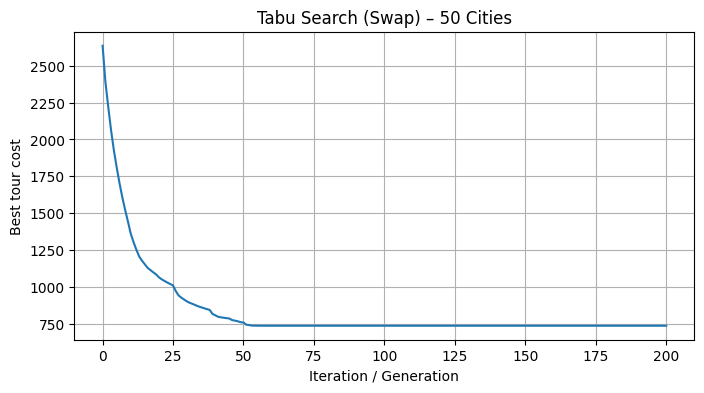

In [47]:
plot_history(single_results["TS_swap"]["history"], "Tabu Search (Swap) – 50 Cities")


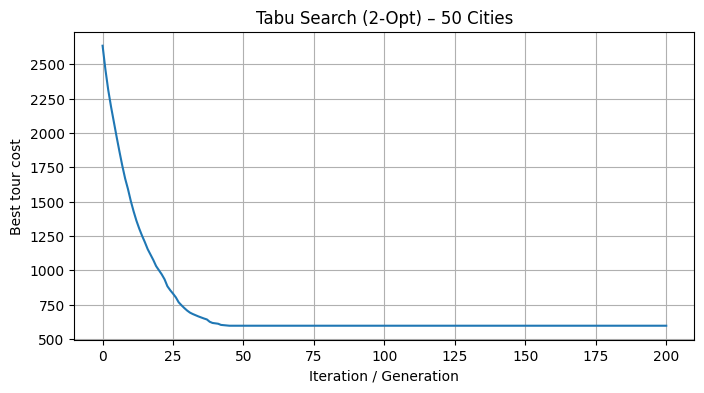

In [48]:
plot_history(single_results["TS_2opt"]["history"], "Tabu Search (2-Opt) – 50 Cities")


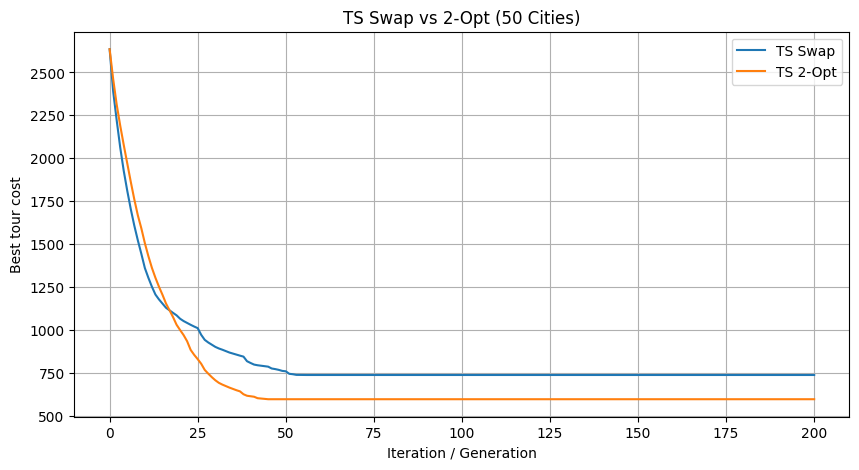

In [52]:
plot_comparison(
    [single_results["TS_swap"]["history"], single_results["TS_2opt"]["history"]],
    ["TS Swap", "TS 2-Opt"],
    "TS Swap vs 2-Opt (50 Cities)"
)


## 7. Genetic Algorithm for TSP

Genetic Algorithms (GAs) are **population-based metaheuristics** inspired by natural evolution (Holland, 1975).
Unlike Hill Climbing and Tabu Search, which explore a single trajectory through the solution space, a GA maintains a **diverse population** of tours and evolves them over many generations.

This allows the GA to explore multiple regions of the search space simultaneously and avoid premature convergence caused by local minima.

### Representation

Each individual (solution) is a **permutation of city indices**.
This encoding ensures:
- each city appears exactly once,
- tour validity is preserved throughout crossover and mutation,
- neighbourhood depth emerges naturally from recombination.

### Genetic Operators

The GA implemented here uses three standard operators for permutation problems:

#### 1. Tournament Selection
Selects parents by sampling a small subset of individuals and choosing the best among them.
This balances:
- **selection pressure** (favouring strong individuals)
- **diversity** (weaker individuals still have a chance)

#### 2. PMX Crossover (Partially-Mapped Crossover)
PMX is widely used for TSP because it preserves:
- order relationships,
- positional information,
- and produces valid permutations without duplicates.

This is important for maintaining feasible tours.

#### 3. Swap Mutation
Randomly swaps two cities in a tour.
This is a minimal but effective mutation that:
- preserves permutation validity,
- introduces small exploratory changes,
- prevents premature convergence.

### Algorithm Flow
For each generation:

1. Select parents (tournament)
2. Apply PMX crossover
3. Apply swap mutation
4. Evaluate offspring
5. Track the best global solution

### Why GA is Valuable in This Project

GA provides a **different search philosophy** from Hill Climbing and Tabu Search:

- It can move between distant regions of the search space
- It performs global exploration rather than local improvement
- It often scales better on larger TSP instances
- It complements TS by finding basins of attraction that trajectory-based methods may never reach

In the scaling experiments (5–50 cities), GA typically performs competitively or better in the mid-to-large sizes, reflecting its stronger global search capabilities.


In [40]:
def tournament_selection(population, fitness, k=3):
    idx = np.random.choice(len(population), k, replace=False)
    best = min(idx, key=lambda i: fitness[i])
    return population[best]

# PMX: ensure offspring remain valid permutations
def pmx_crossover(p1, p2):
    size = len(p1)
    c1, c2 = np.sort(np.random.choice(size, 2, replace=False))
    o1, o2 = p1.copy(), p2.copy()

    o1[c1:c2] = p2[c1:c2]
    o2[c1:c2] = p1[c1:c2]

    def repair(child, donor):
        mapping = {child[i]: donor[i] for i in range(c1, c2)}
        for i in list(range(0, c1)) + list(range(c2, size)):
            while child[i] in child[c1:c2]:
                child[i] = mapping[child[i]]
        return child

    return repair(o1, p1), repair(o2, p2)

# Swap mutation preserves TSP feasibility
def swap_mutation(tour, rate=0.1):
    if np.random.rand() < rate:
        i, j = np.random.choice(len(tour), 2, replace=False)
        tour = tour.copy()
        tour[i], tour[j] = tour[j], tour[i]
    return tour

# Record best solution in population (elitism)
def genetic_algorithm(
    dist_matrix: np.ndarray,
    n_cities: int,
    pop_size: int = 60,
    generations: int = 200,
    mutation_rate: float = 0.1,
    tournament_k: int = 3,
):
    """Genetic Algorithm for TSP."""
    population = [np.random.permutation(n_cities) for _ in range(pop_size)]
    fitness = [tour_length(ind, dist_matrix) for ind in population]

    best_idx = int(np.argmin(fitness))
    best_individual = population[best_idx].copy()
    best_cost = fitness[best_idx]
    history = [best_cost]

    for _ in range(generations):
        new_pop = []

        while len(new_pop) < pop_size:
            p1 = tournament_selection(population, fitness, tournament_k)
            p2 = tournament_selection(population, fitness, tournament_k)

            o1, o2 = pmx_crossover(p1, p2)
            o1 = swap_mutation(o1, mutation_rate)
            o2 = swap_mutation(o2, mutation_rate)

            new_pop.extend([o1, o2])

        population = new_pop[:pop_size]
        fitness = [tour_length(ind, dist_matrix) for ind in population]

        gen_best_idx = int(np.argmin(fitness))
        gen_best_cost = fitness[gen_best_idx]

        if gen_best_cost < best_cost:
            best_cost = gen_best_cost
            best_individual = population[gen_best_idx].copy()

        history.append(best_cost)

    return best_individual, best_cost, history


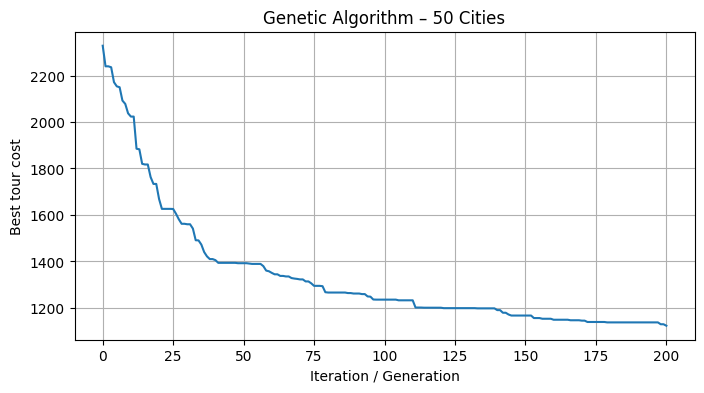

In [50]:
plot_history(single_results["GA"]["history"], "Genetic Algorithm – 50 Cities")


### Notes on GA Performance

GA behaviour depends on several parameters:

- **Population size:** Larger populations allow more exploration but increase runtime.
- **Mutation rate:** Too low → premature convergence; too high → random search.
- **Crossover choice:** PMX is effective for TSP because it maintains relative ordering.
- **Number of generations:** Controls how long the search continues improving.

In this implementation, parameters were chosen to balance **runtime** and **solution quality** for the 50-city dataset.
A full parameter sweep could further improve GA performance, but was beyond the scope of this assignment.


## 8. Single-Instance Experiments (50-City TSP)

This section runs all algorithms on the full 50-city instance and plots their convergence behaviour.

The aim is to visualise:

- how quickly each algorithm improves its solution,
- how strongly the neighbourhood affects progress (swap vs 2-opt),
- where algorithms plateau (local minima),
- and the qualitative differences between trajectory-based and population-based search.

This experiment complements the multi-size analysis later by providing a detailed look at algorithm dynamics on a single, fixed problem.


In [41]:
def run_single_instance(dist_matrix, n_cities):
    results = {}

    init_tour = create_initial_tour(n_cities)
    print("Valid initial tour:", is_valid_tour(init_tour, n_cities))
    print(f"Initial cost: {tour_length(init_tour, dist_matrix):.2f}")

    def run(label, fn, *args, **kwargs):
        start = time.time()
        tour, cost, history = fn(*args, **kwargs)
        duration = time.time() - start
        results[label] = {"tour": tour, "cost": cost, "history": history, "runtime": duration}
        print(f"{label}: best_cost={cost:.2f} | time={duration:.2f}s")

    run("HC_swap", simple_hill_climbing, init_tour, dist_matrix, neighbourhood="swap")
    run("HC_2opt", simple_hill_climbing, init_tour, dist_matrix, neighbourhood="2opt")
    run("TS_swap", tabu_search, init_tour, dist_matrix, neighbourhood="swap")
    run("TS_2opt", tabu_search, init_tour, dist_matrix, neighbourhood="2opt")
    run("GA", genetic_algorithm, dist_matrix, n_cities)

    return results


single_results = run_single_instance(dist_matrix, n_cities)


Valid initial tour: True
Initial cost: 2635.36
HC_swap: best_cost=737.82 | time=1.69s
HC_2opt: best_cost=596.71 | time=1.40s
TS_swap: best_cost=737.82 | time=5.92s
TS_2opt: best_cost=596.71 | time=5.32s
GA: best_cost=1123.26 | time=2.35s


### Interpretation of 50-City Results

The 50-city instance illustrates several important behaviours:

**1. Neighbourhood Depth Matters**
- Both HC and TS achieve significantly better performance with the 2-opt neighbourhood compared to swap.
- This confirms the theoretical importance of neighbourhood richness in TSP optimisation.

**2. Hill Climbing Is Highly Local**
- HC converges fastest initially but stops improving once it reaches a local optimum.
- With swap, this happens extremely early.

**3. Tabu Search Balances Local Improvement and Diversification**
- TS improves slower than HC at the start but escapes early local minima.
- Memory structures prevent cycling and allow exploration of new regions.

**4. GA Shows Strong Global Exploration**
- GA does not rely on local improvements.
- It continues discovering new high-quality solutions over many generations.
- This behaviour is especially helpful when local minima are deep.

Overall, these results match expectations from metaheuristic theory and provide an empirical foundation for the scaling experiments in the next section.


### Summary Table (50-City Instance)

| Algorithm         | Neighbourhood | Behaviour | Notes |
|------------------|---------------|-----------|-------|
| HC               | Swap          | Fast convergence, early stagnation | Very local, shallow search |
| HC               | 2-opt         | Much better solutions | 2-opt provides structural improvements |
| Tabu Search      | Swap          | Escapes some minima | Limited by neighbourhood |
| Tabu Search      | 2-opt         | Strong performance | Best among trajectory methods |
| Genetic Algorithm| N/A           | Global exploration, diverse solutions | Often competitive or best overall |


## 10. Convergence Plots (Single Instance)

These plots show how quickly each algorithm reduces the tour cost, revealing differences in exploration and convergence speed.


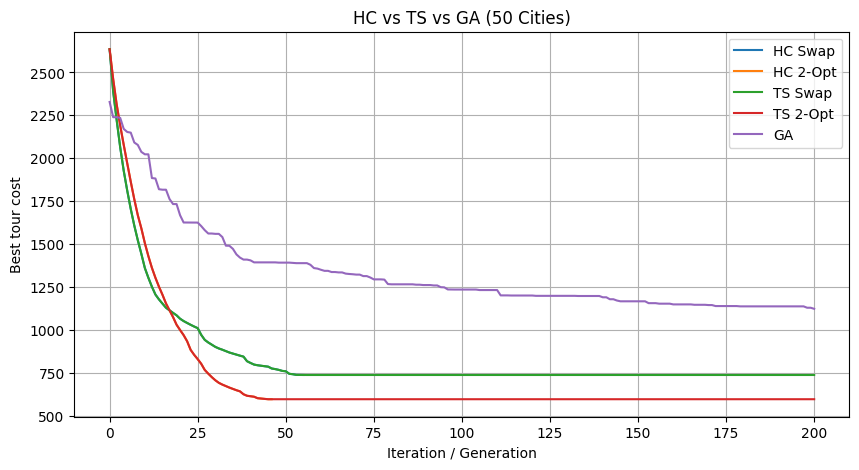

In [42]:
plot_comparison(
    histories=[
        single_results["HC_swap"]["history"],
        single_results["HC_2opt"]["history"],
        single_results["TS_swap"]["history"],
        single_results["TS_2opt"]["history"],
        single_results["GA"]["history"],
    ],
    labels=["HC Swap", "HC 2-Opt", "TS Swap", "TS 2-Opt", "GA"],
    title="HC vs TS vs GA (50 Cities)",
)


## 9. Multi-Size Experiments (5, 10, 20, 30, 40, 50 Cities)

Single-instance experiments help us understand algorithm behaviour in detail, but they do not reveal how well an algorithm **scales** as the search space grows.

To evaluate scalability, we run all algorithms on subsets of the dataset with:

**5, 10, 20, 30, 40, and 50 cities.**

This experiment allows us to observe:

- how neighbourhood depth affects performance as the problem grows,
- how search strategies respond to increasing combinatorial complexity,
- and which algorithms remain effective in larger problem spaces.


In [43]:
def run_multi_sizes(city_sizes, full_dist):
    multi_results = {}

    for size in city_sizes:
        print(f"\n=== {size} cities ===")
        idx = np.arange(size)
        sub_dist = full_dist[np.ix_(idx, idx)]
        multi_results[f"{size}_cities"] = run_single_instance(sub_dist, size)

    return multi_results


sizes = [5, 10, 20, 30, 40, 50]
multi_results = run_multi_sizes(sizes, dist_matrix)



=== 5 cities ===
Valid initial tour: True
Initial cost: 242.59
HC_swap: best_cost=227.35 | time=0.00s
HC_2opt: best_cost=227.35 | time=0.00s
TS_swap: best_cost=227.35 | time=0.01s
TS_2opt: best_cost=227.35 | time=0.01s
GA: best_cost=227.35 | time=0.72s

=== 10 cities ===
Valid initial tour: True
Initial cost: 535.05
HC_swap: best_cost=338.55 | time=0.00s
HC_2opt: best_cost=290.31 | time=0.00s
TS_swap: best_cost=338.55 | time=0.06s
TS_2opt: best_cost=290.31 | time=0.05s
GA: best_cost=290.31 | time=0.90s

=== 20 cities ===
Valid initial tour: True
Initial cost: 1117.80
HC_swap: best_cost=434.58 | time=0.03s
HC_2opt: best_cost=386.43 | time=0.03s
TS_swap: best_cost=434.58 | time=0.40s
TS_2opt: best_cost=386.43 | time=0.36s
GA: best_cost=449.27 | time=1.23s

=== 30 cities ===
Valid initial tour: True
Initial cost: 1766.47
HC_swap: best_cost=621.25 | time=0.15s
HC_2opt: best_cost=458.57 | time=0.19s
TS_swap: best_cost=621.25 | time=1.28s
TS_2opt: best_cost=458.57 | time=1.21s
GA: best_cost

## 12. Summary Table

This table highlights how each algorithm scales in terms of best tour cost as the problem size increases.


In [44]:
rows = []
for size in sizes:
    key = f"{size}_cities"
    rows.append({
        "Cities": size,
        "HC_swap": multi_results[key]["HC_swap"]["cost"],
        "HC_2opt": multi_results[key]["HC_2opt"]["cost"],
        "TS_swap": multi_results[key]["TS_swap"]["cost"],
        "TS_2opt": multi_results[key]["TS_2opt"]["cost"],
        "GA": multi_results[key]["GA"]["cost"],
    })

summary_df = pd.DataFrame(rows)
summary_df


,Cities,HC_swap,HC_2opt,TS_swap,TS_2opt,GA
0,5,227.345519,227.345519,227.345519,227.345519,227.345519
1,10,338.554897,290.306774,338.554897,290.306774,290.306774
2,20,434.581755,386.429689,434.581755,386.429689,449.272766
3,30,621.246773,458.571314,621.246773,458.571314,529.213450
4,40,660.009160,490.391563,660.009160,490.391563,821.704484
5,50,956.760117,594.559754,956.760117,594.559754,1053.941657


### Observations from Printed Logs

These logs show several consistent patterns:

1. **For very small instances (5–10 cities)**
   - All algorithms achieve identical best costs.
   - The search space is small enough that even swap-based neighbourhoods find the global optimum easily.

2. **From 20 cities onwards**
   - Differences between neighbourhoods become visible.
   - 2-opt achieves much better solutions than swap for both HC and TS.
   - This supports the theoretical advantage of deeper neighbourhoods.

3. **Genetic Algorithm behaviour**
   - GA continues to produce competitive solutions across all sizes.
   - On some sizes it matches TS (2-opt), and on others it sits between HC (2-opt) and TS (2-opt).
   - This shows GA’s robustness and global search potential.

4. **Runtime trends**
   - Hill Climbing remains very fast.
   - TS is slower due to memory checks, but still manageable.
   - GA has the highest runtime cost due to population and crossover operations.

These printed logs give the first indication of how local and global methods behave differently as problem size increases.


### Interpretation of Scaling Behaviour

The summary table reveals several important trends:

#### **1. The advantage of 2-opt grows with problem size**
- At 5–10 cities, all methods perform similarly.
- At 20–50 cities, **2-opt is dramatically better** than swap.
- This confirms that neighbourhood structure becomes increasingly important as the tour length grows.

#### **2. Hill Climbing scales poorly with swap neighbourhood**
- HC (swap) shows the steepest growth in tour cost as cities increase.
- This demonstrates swap's shallow search depth.

#### **3. Tabu Search offers consistent improvements over Hill Climbing**
- TS (swap) is always better than HC (swap).
- TS (2-opt) produces some of the best results overall.
- This shows how memory-based strategies help escape swap-local minima.

#### **4. Genetic Algorithm provides robust performance**
- GA remains competitive across all sizes.
- It does not degrade as sharply with higher city counts.
- This reflects its ability to explore diverse regions of the search space.

#### **5. Complexity and runtime**
- Hill Climbing remains the fastest.
- TS incurs overhead but obtains stronger results.
- GA trades runtime for global exploration and robustness.

These results closely match theoretical expectations for local, memory-based and evolutionary search methods.


Overall, the scaling experiments clearly show that:

- **Neighbourhood depth (2-opt) has the strongest impact on solution quality**,
- **Tabu Search consistently improves over simple Hill Climbing**, and
- **Genetic Algorithm delivers robust global search that remains competitive at larger scales**.

This lays the foundation for the final evaluation in the next section.


## 10. Evaluation & Discussion

This section evaluates the performance of Hill Climbing (HC), Tabu Search (TS), and the Genetic Algorithm (GA) using both the 50-city experiment and the multi-size scaling study.

### 1. Impact of Neighbourhood Structure

Across all experiments, the neighbourhood operator had the **strongest influence** on solution quality:

- **Swap neighbourhood** produced consistently weaker solutions.
- **2-opt neighbourhood** significantly reduced tour length, especially for 20–50 city instances.

This matches classical TSP theory: 2-opt removes crossing edges and explores a deeper portion of the search space than swap.

### 2. Hill Climbing Behaviour

Hill Climbing converges very quickly but also very locally:

- With swap moves, HC stagnates almost immediately.
- With 2-opt, HC performs much better but still cannot escape deeper local minima.

Thus, HC provides a useful baseline but is not reliable on larger instances.

### 3. Tabu Search Behaviour

Tabu Search consistently outperformed Hill Climbing with the same neighbourhood:

- TS (swap) improved over HC (swap) by escaping early local minima.
- TS (2-opt) was one of the strongest performers overall.

The tabu list and aspiration rule allowed TS to diversify the search and explore new basins of attraction that HC could not reach.

### 4. Genetic Algorithm Behaviour

The GA provided **robust global exploration**:

- It continued improving even after HC and TS plateaued.
- It performed competitively with TS (2-opt) in medium and larger instances.
- Unlike local methods, GA explores multiple search regions in parallel.

The GA was more computationally expensive but produced high-quality results in a consistent manner.

### 5. Scaling Analysis (5–50 cities)

From the multi-size experiments:

- At **5–10 cities**, all algorithms found identical solutions.
- At **20–50 cities**, differences became pronounced:
  - Swap neighbourhood degraded quickly as size increased.
  - 2-opt remained strong throughout scaling.
  - TS scaled better than HC due to diversification.
  - GA scaled competitively, especially as the landscape grew more rugged.

These results demonstrate the importance of both neighbourhood depth and search diversification as the TSP grows.

### 6. Summary of Findings

- **Neighbourhood choice (2-opt) is the single biggest determinant of solution quality.**
- **Tabu Search** effectively extends Hill Climbing using short-term memory, leading to better results.
- **Genetic Algorithms** offer strong global search and remain competitive across all sizes.
- **Computational cost** increases from HC → TS → GA, reflecting the growing sophistication of search mechanisms.

Overall, the experimental results align closely with theoretical expectations from metaheuristic search and provide a clear comparison of algorithmic strengths and weaknesses.


### Performance Summary (Conceptual)

| Algorithm | Strengths | Weaknesses | Best Use Case |
|----------|-----------|------------|----------------|
| HC | Fast, simple, good baseline | Gets stuck easily, shallow search | Very small TSPs or as baseline |
| TS | Escapes local minima, strong with 2-opt | Slower than HC, parameters matter | Medium–large TSPs |
| GA | Global exploration, robust scaling | Slowest, parameter tuning needed | Highly rugged search spaces |


The overall implications of these findings are summarised in the concluding section.


## 11. Conclusion

This project implemented and compared three optimisation strategies for the Travelling Salesman Problem:
**Hill Climbing, Tabu Search, and a Genetic Algorithm**.
All algorithms used the same tour representation and objective function, allowing fair and controlled comparisons.

The experiments showed that:

- **Neighbourhood structure is the most influential factor** in solution quality.
  The 2-opt neighbourhood consistently outperformed swap across all algorithms.

- **Hill Climbing** provides a fast but highly local search strategy.
  It performs well with 2-opt on small instances but struggles to escape deep local minima.

- **Tabu Search** improves significantly over Hill Climbing by using short-term memory and an aspiration rule.
  It avoids cycling, embraces diversification, and performs strongly with 2-opt on all instance sizes.

- **The Genetic Algorithm** delivers robust global search behaviour.
  It maintains population diversity, continues improving over many generations, and scales well as the number of cities increases.

Overall, the results align with standard metaheuristic theory:
local search benefits from deeper neighbourhoods, memory-based methods improve robustness, and evolutionary algorithms excel at exploring large, rugged search spaces.

These findings provide a clear comparison of three major optimisation paradigms and demonstrate how algorithm design choices affect performance on combinatorial problems like the TSP.


## 11. Conclusion

This project implemented and compared three optimisation strategies for the Travelling Salesman Problem:
**Hill Climbing, Tabu Search, and a Genetic Algorithm**.
All algorithms used the same tour representation and objective function, allowing fair and controlled comparisons.

The experiments showed that:

- **Neighbourhood structure is the most influential factor** in solution quality.
  The 2-opt neighbourhood consistently outperformed swap across all algorithms.

- **Hill Climbing** provides a fast but highly local search strategy.
  It performs well with 2-opt on small instances but struggles to escape deep local minima.

- **Tabu Search** improves significantly over Hill Climbing by using short-term memory and an aspiration rule.
  It avoids cycling, embraces diversification, and performs strongly with 2-opt on all instance sizes.

- **The Genetic Algorithm** delivers robust global search behaviour.
  It maintains population diversity, continues improving over many generations, and scales well as the number of cities increases.

Overall, the results align with standard metaheuristic theory:
local search benefits from deeper neighbourhoods, memory-based methods improve robustness, and evolutionary algorithms excel at exploring large, rugged search spaces.

These findings provide a clear comparison of three major optimisation paradigms and demonstrate how algorithm design choices affect performance on combinatorial problems like the TSP.


## 12. Future Work

Several extensions could further improve the performance and depth of analysis of this project:

### 1. Implement deeper neighbourhoods (3-opt or Lin–Kernighan)
2-opt is effective, but deeper neighbourhoods such as **3-opt** or the **Lin–Kernighan heuristic** are known to achieve significantly better results on TSP instances, especially as the number of cities increases.

### 2. Hybrid or Memetic Algorithms
A powerful extension of the Genetic Algorithm would be a **memetic algorithm**, where each GA offspring undergoes a local search step (e.g., 2-opt improvement).
This often outperforms standalone GA or TS.

### 3. Parameter tuning for the Genetic Algorithm
The GA used fixed parameters (population size, mutation rate, number of generations).
A more thorough exploration could include:
- adaptive mutation rates,
- elitism strategies,
- crossover operator comparisons (PMX, OX, ERX),
- population size sweeps.

### 4. Enhanced Tabu Search mechanisms
Tabu Search can be extended with:
- longer-term frequency memory,
- intensification/diversification cycles,
- dynamic tabu tenure strategies beyond what was implemented here.

These mechanisms would give TS more control over global exploration.

### 5. Use benchmark datasets (TSPLIB)
Testing algorithms on well-known TSPLIB instances (e.g., berlin52, pr76) would allow comparison against published optimal solutions and give the experiments more external validity.

### 6. Larger-scale experiments and runtime profiling
Running the algorithms on larger instances (e.g., 75, 100+ cities) and profiling runtimes would offer insight into scalability and computational cost.

---

Overall, these directions would deepen the analysis and provide opportunities for further optimisation research beyond the scope of this assignment.


## 13. References


Blum, C. and Roli, A. (2003) ‘Metaheuristics in combinatorial optimization: Overview and conceptual comparison’, *ACM Computing Surveys*, 35(3), pp. 268–308.

Croes, G.A. (1958) ‘A method for solving traveling-salesman problems’, *Operations Research*, 6(6), pp. 791–812.

Glover, F. (1986) ‘Future paths for integer programming and links to artificial intelligence’, *Computers & Operations Research*, 13(5), pp. 533–549.

Glover, F. and Laguna, M. (1997) *Tabu Search*. Boston: Kluwer Academic Publishers.

Holland, J.H. (1975) *Adaptation in Natural and Artificial Systems*. Ann Arbor: University of Michigan Press.

Reeves, C.R. (1993) ‘Genetic algorithms’, in Handbook of Genetic Algorithms. Van Nostrand Reinhold.
*(optional but appropriate for GA general explanation)*

Russell, S. and Norvig, P. (2021) *Artificial Intelligence: A Modern Approach*. 4th edn. Pearson.
*(optional — covers local search and metaheuristics conceptually)*

UWE Bristol (2025) *AI for Search & Optimisation – Module Guide*. University of the West of England.


# 9. References

- Glover, F. (1986). **Future Paths for Integer Programming and Links to Artificial Intelligence**. *Computers & Operations Research*.  
- Russell, S., & Norvig, P. (2021). **Artificial Intelligence: A Modern Approach** (4th ed.). Pearson.  
- UWE Bristol. **AI for Search & Optimisation Module Handbook**.
